Model                 Train Acc   Test Acc     CV Acc
Random Forest            1.0000     0.9955     0.9950
Naive Bayes              0.9949     0.9955     0.9950
SVM                      0.9858     0.9841     0.9823
Decision Tree            1.0000     0.9795     0.9868

Best model: Random Forest (99.55%)

Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0

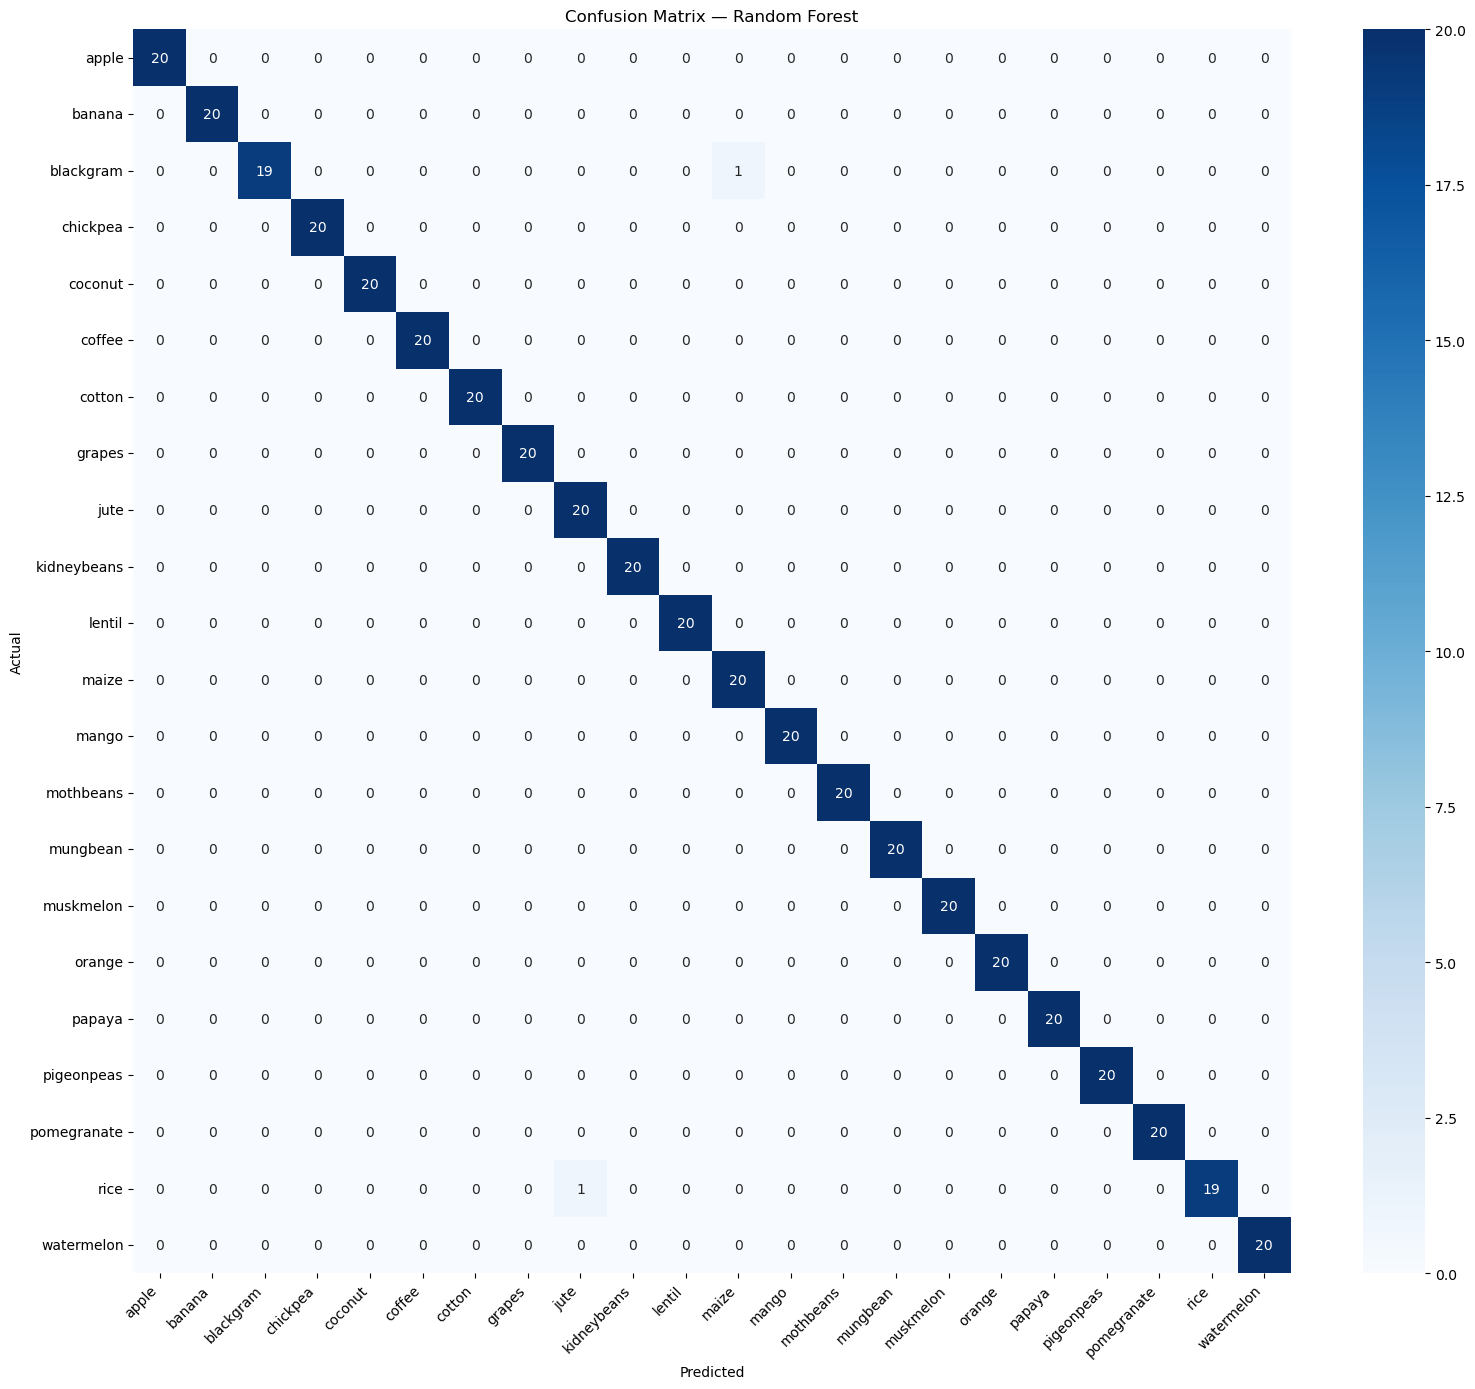

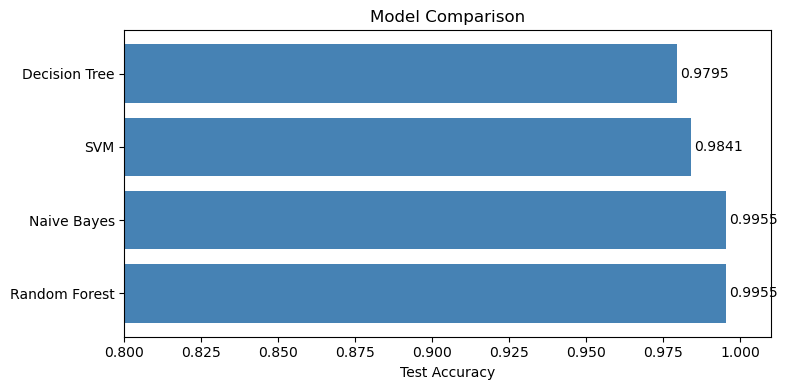

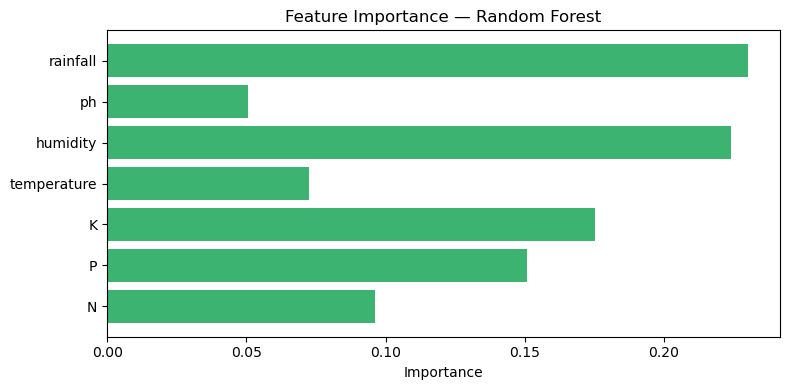


Model saved as model.pkl ✓
Scaler saved as scaler.pkl ✓
Encoder saved as encoder.pkl ✓


In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusoad data ──────────────────────────────────────────────
df = pd.read_csv("Crop_recommendation.csv")

features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
X = df[features].values
y = df['label'].values

# ── Encode labels ──────────────────────────────────────────
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ── Scale features ─────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Train/test split ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ── Compare multiple models ────────────────────────────────
models = {
    "Random Forest":   RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes":     GaussianNB(),
    "SVM":             SVC(kernel='rbf', random_state=42),
    "Decision Tree":   DecisionTreeClassifier(random_state=42),
}

print("=" * 50)
print(f"{'Model':<20} {'Train Acc':>10} {'Test Acc':>10} {'CV Acc':>10}")
print("=" * 50)

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    cv_acc    = cross_val_score(model, X_scaled, y_encoded, cv=5).mean()
    results[name] = test_acc
    print(f"{name:<20} {train_acc:>10.4f} {test_acc:>10.4f} {cv_acc:>10.4f}")
print("=" * 50)

# ── Pick best model ────────────────────────────────────────
best_name = max(results, key=results.get)
best_model = models[best_name]
print(f"\nBest model: {best_name} ({results[best_name]*100:.2f}%)")

# ── Detailed report for best model ────────────────────────
y_pred = best_model.predict(X_test)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# ── Confusion matrix ───────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.title(f"Confusion Matrix — {best_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

# ── Model accuracy bar chart ───────────────────────────────
plt.figure(figsize=(8, 4))
plt.barh(list(results.keys()), list(results.values()), color='steelblue')
plt.xlabel("Test Accuracy")
plt.title("Model Comparison")
plt.xlim(0.8, 1.01)
for i, v in enumerate(results.values()):
    plt.text(v + 0.001, i, f"{v:.4f}", va='center')
plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()

# ── Feature importance (if Random Forest is best) ─────────
if best_name == "Random Forest":
    importances = best_model.feature_importances_
    plt.figure(figsize=(8, 4))
    plt.barh(features, importances, color='mediumseagreen')
    plt.xlabel("Importance")
    plt.title("Feature Importance — Random Forest")
    plt.tight_layout()
    plt.savefig("feature_importance.png")
    plt.show()

# ── Save model, scaler, and label encoder ─────────────────
with open("model.pkl",   "wb") as f: pickle.dump(best_model, f)
with open("scaler.pkl",  "wb") as f: pickle.dump(scaler, f)
with open("encoder.pkl", "wb") as f: pickle.dump(le, f)

print("\nModel saved as model.pkl ✓")
print("Scaler saved as scaler.pkl ✓")
print("Encoder saved as encoder.pkl ✓")